# PHẦN 0 - Notebook setup
Mục tiêu phân tích: Set up môi trường, import thư viện và tạo các hàm hỗ trợ.


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')

# Set vibrant colorful visualization style globally
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=sns.color_palette("husl", 15))

# Set display options
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Global variables/thresholds based on requirements
MIN_CAMPAIGN_NPU_FOR_AVG = 30
MIN_CAMPAIGN_NPU_FOR_RETENTION = 100

# Helper functions
def standardize_col_names(df):
    df.columns = df.columns.str.strip().str.replace(' ', '_')
    return df

def get_df_info(df, name="Dataframe"):
    print(f"--- {name} ---")
    print(f"Shape: {df.shape}")
    display(df.head())
    
def get_missing_rate(df):
    missing = df.isnull().sum()
    missing_rate = (missing / len(df)) * 100
    missing_df = pd.DataFrame({'Missing Count': missing, 'Missing Rate (%)': missing_rate})
    return missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Rate (%)', ascending=False)

def format_large_number(num):
    if num >= 1e9:
        return f"{num/1e9:.2f}B"
    elif num >= 1e6:
        return f"{num/1e6:.2f}M"
    elif num >= 1e3:
        return f"{num/1e3:.2f}K"
    return str(num)


# PHẦN 1 - Business understanding
- Bài toán không chỉ hỏi campaign nào kéo nhiều NPU nhất.
- Bài toán quan trọng hơn là campaign nào kéo được NPU có chất lượng (hành vi tốt sau giao dịch đầu tiên).
- Notebook này **CHỈ LÀM EDA** (Exploratory Data Analysis) để hiểu dữ liệu, dọn dẹp các anomalies và chuẩn bị nền cho các phần sau.
- Các phần sau sẽ gồm:
  + Campaign quality framework
  + Dashboard
  + Campaign ranking
  + Recommendation
*Nhưng các phần đó chưa làm trong notebook này.*


# PHẦN 2 - Load data
Mục tiêu: Đọc 3 file Excel `user_info.xlsx`, `merchant_info.xlsx`, `transaction_info.xlsx`. In ra shape và 5 dòng đầu tiên, kiểm tra các thuộc tính cơ bản.


In [18]:
# Đọc dữ liệu
try:
    df_user = pd.read_excel('user_info.xlsx')
    df_merchant = pd.read_excel('merchant_info.xlsx')
    df_transaction = pd.read_excel('transaction_info.xlsx')
    print("Loaded data successfully!")
except Exception as e:
    print(f"Lỗi load data (có thể file không tồn tại): {e}")
    # Dummy data initialization for structure continuity
    df_user = pd.DataFrame(columns=['userID', 'gender', 'created_account_date'])
    df_merchant = pd.DataFrame(columns=['appID', 'report_sub_cat', 'report_cat'])
    df_transaction = pd.DataFrame(columns=['transID', 'userID', 'sof', 'platform', 'appID', 'deviceID', 'userIP', 'reqDate', 'amount', 'userChargeAmount', 'discountAmount', 'transStatus', 'campaignID', 'promotion_type'])

get_df_info(df_user, "user_info")
get_df_info(df_merchant, "merchant_info")
get_df_info(df_transaction, "transaction_info")


Loaded data successfully!
--- user_info ---
Shape: (33686, 3)


,userID,gender,created_account_date
0,de24865d2b54eb0f38d09ae3aa59b6ee,female,2017-07-03
1,afb67f66907dd2d57919a72820d2488f,female,2018-04-24
2,2e2ae15ca6a7236b79c5eae71aa3256f,male,2018-09-26
3,ab61f0a7d5dcf5ca399b948a1ba90517,male,2018-11-02
4,d7ec625fd5e8f259de6538c70d2d9058,female,2018-12-11


--- merchant_info ---
Shape: (748, 3)


,appID,report_cat,report_sub_cat
0,1403,Obligation_Payment,Obligation_Payment_Utility_Service
1,1059,Obligation_Payment,Obligation_Payment_Utility_Service
2,889,Obligation_Payment,Obligation_Payment_Loan_Repayment
3,1110,Obligation_Payment,Obligation_Payment_Utility_Service
4,417,Obligation_Payment,Obligation_Payment_Loan_Repayment


--- transaction_info ---
Shape: (301107, 14)


,transID,userID,sof,platform,appID,deviceID,userIP,reqDate,amount,userChargeAmount,discountAmount,transStatus,campaignID,promotion_type
0,a3a41dc5672b84429dcea8d7b495ec3c,869ddd0dfb5335cba981750b64d86f5f,sof3,platform3,24,8738fc9f87128290ed8474dcb672231b,708f658693a2e43632e3953d7135502a,2022-10-23 11:36:40.380,48500,28500,20000,1,9945,voucher
1,4771dea5fc29cbbff74750b8b827a68c,891db526845fb7c95ecfe6c8b187e380,sof3,platform1,748,NaN,891db526845fb7c95ecfe6c8b187e380,2022-10-22 18:13:05.372,49800,29800,20000,1,9945,voucher
2,21072972ff937114bd96364f526cd9d0,b0b9e303379c38407ca75c526f1394d6,sof3,platform1,748,NaN,b0b9e303379c38407ca75c526f1394d6,2022-10-25 00:14:58.213,171175,151175,20000,1,9945,voucher
3,9b5823d4f0bd359bfe537c3ce9e3324f,b6aa3b4ac92e40b79a3b14e8d8397e2d,sof2,platform1,24,2812775e1e29f04aa29fa38cf810cf74,db9fdfb5ff746e81ed461a1ba8192b84,2022-10-25 16:14:53.959,50000,30000,20000,1,9945,voucher
4,b930bf1100c0c461fa85a04a365dc9e8,fe22f49da3279032ab408277cb3bbbc9,sof3,platform1,748,NaN,fe22f49da3279032ab408277cb3bbbc9,2022-10-25 23:02:30.740,68100,48100,20000,1,9945,voucher


# PHẦN 3 - Data dictionary & schema audit
Mục tiêu:
- Hiểu cấu trúc dữ liệu
- Phát hiện cột ngày tháng cần convert
- Phát hiện categorical/numerical/ID columns


In [19]:
def create_schema_audit(df):
    schema = pd.DataFrame({
        'column name': df.columns,
        'dtype': df.dtypes.values,
        'non-null count': df.notnull().sum().values,
        'missing count': df.isnull().sum().values,
        'missing rate (%)': (df.isnull().sum().values / len(df) * 100).round(2) if len(df) > 0 else 0,
        'number of unique values': df.nunique().values
    })
    
    sample_values = []
    for col in df.columns:
        valid_samples = df[col].dropna().unique()
        sample_values.append(list(valid_samples[:3]) if len(valid_samples) > 0 else [])
    
    schema['sample values'] = sample_values
    return schema

print("Schema Audit - user_info:")
display(create_schema_audit(df_user))

print("\nSchema Audit - merchant_info:")
display(create_schema_audit(df_merchant))

print("\nSchema Audit - transaction_info:")
display(create_schema_audit(df_transaction))


Schema Audit - user_info:


,column name,dtype,non-null count,missing count,missing rate (%),number of unique values,sample values
0,userID,object,33686,0,0.000,33686,"[de24865d2b54eb0f38d09ae3aa59b6ee, afb67f66907..."
1,gender,object,33686,0,0.000,3,"[female, male, unknown]"
2,created_account_date,datetime64[ns],33686,0,0.000,1785,"[2017-07-03 00:00:00, 2018-04-24 00:00:00, 201..."



Schema Audit - merchant_info:


,column name,dtype,non-null count,missing count,missing rate (%),number of unique values,sample values
0,appID,int64,748,0,0.000,748,"[1403, 1059, 889]"
1,report_cat,object,748,0,0.000,12,"[Obligation_Payment, Goods_Transaction, Unknow..."
2,report_sub_cat,object,748,0,0.000,60,"[Obligation_Payment_Utility_Service, Obligatio..."



Schema Audit - transaction_info:


,column name,dtype,non-null count,missing count,missing rate (%),number of unique values,sample values
0,transID,object,301107,0,0.000,301107,"[a3a41dc5672b84429dcea8d7b495ec3c, 4771dea5fc2..."
1,userID,object,301107,0,0.000,33664,"[869ddd0dfb5335cba981750b64d86f5f, 891db526845..."
2,sof,object,301107,0,0.000,6,"[sof3, sof2, sof4]"
3,platform,object,300340,767,0.250,3,"[platform3, platform1, platform2]"
4,appID,int64,301107,0,0.000,748,"[24, 748, 417]"
5,deviceID,object,272560,28547,9.480,45052,"[8738fc9f87128290ed8474dcb672231b, 2812775e1e2..."
6,userIP,object,301107,0,0.000,114758,"[708f658693a2e43632e3953d7135502a, 891db526845..."
7,reqDate,object,301107,0,0.000,301099,"[2022-10-23 11:36:40.380, 2022-10-22 18:13:05...."
8,amount,int64,301107,0,0.000,20760,"[48500, 49800, 171175]"
9,userChargeAmount,int64,301107,0,0.000,28545,"[28500, 29800, 151175]"


# PHẦN 4 - Data quality check
Mục tiêu: Kiểm tra duplicate, missing values, lỗi value logic và các anomaly liên quan đến promotion.


In [20]:
# 4.1 Duplicate check
print("--- 4.1 Duplicate ---")
print(f"user_info duplicate rows: {df_user.duplicated().sum()}")
if 'userID' in df_user.columns:
    print(f"user_info duplicate userID: {df_user.duplicated(subset=['userID']).sum()}")

print(f"\nmerchant_info duplicate rows: {df_merchant.duplicated().sum()}")
if 'appID' in df_merchant.columns:
    print(f"merchant_info duplicate appID: {df_merchant.duplicated(subset=['appID']).sum()}")

print(f"\ntransaction_info duplicate rows: {df_transaction.duplicated().sum()}")
if 'transID' in df_transaction.columns:
    print(f"transaction_info duplicate transID: {df_transaction.duplicated(subset=['transID']).sum()}")

# 4.2 Missing values
print("\n--- 4.2 Missing values ---")
print("Missing rates in transaction_info:")
display(get_missing_rate(df_transaction))

# 4.3 Data type conversion
print("\n--- 4.3 Data type conversion ---")
if 'created_account_date' in df_user.columns:
    df_user['created_account_date'] = pd.to_datetime(df_user['created_account_date'], errors='coerce')
    print(f"user_info parse date errors: {df_user['created_account_date'].isnull().sum()}")

if 'reqDate' in df_transaction.columns:
    df_transaction['reqDate'] = pd.to_datetime(df_transaction['reqDate'], errors='coerce')
    print(f"transaction_info parse date errors: {df_transaction['reqDate'].isnull().sum()}")

# 4.4 Value validation
print("\n--- 4.4 Value validation ---")
if len(df_transaction) > 0:
    print(f"amount < 0: {(df_transaction['amount'] < 0).sum()} rows")
    print(f"userChargeAmount < 0: {(df_transaction['userChargeAmount'] < 0).sum()} rows")
    print(f"discountAmount < 0: {(df_transaction['discountAmount'] < 0).sum()} rows")
    if 'amount' in df_transaction.columns and 'userChargeAmount' in df_transaction.columns:
        print(f"userChargeAmount > amount: {(df_transaction['userChargeAmount'] > df_transaction['amount']).sum()} rows")
    print(f"transStatus values: {df_transaction['transStatus'].unique()}")
    print(f"campaignID null: {df_transaction['campaignID'].isnull().sum()} rows")
    print(f"promotion_type values: {df_transaction['promotion_type'].unique()}")
    print(f"reqDate range: {df_transaction['reqDate'].min()} to {df_transaction['reqDate'].max()}")

# 4.5 Promotion anomaly
print("\n--- 4.5 Promotion anomaly ---")
if len(df_transaction) > 0:
    df_transaction['promotion_anomaly'] = (df_transaction['discountAmount'] > 0) & (df_transaction['promotion_type'].isnull())
    print(f"Promotion anomaly rows: {df_transaction['promotion_anomaly'].sum()}")
    
    # Flag without dropping
    conditions = [
        (df_transaction['promotion_type'].isnull()) & (df_transaction['discountAmount'] > 0),
        (df_transaction['promotion_type'].isnull()) & ((df_transaction['discountAmount'] == 0) | df_transaction['discountAmount'].isnull())
    ]
    choices = ['unknown_promotion', 'no_promotion']
    df_transaction['promotion_type_clean'] = np.select(conditions, choices, default=df_transaction['promotion_type'])
    
    print("\npromotion_type_clean distribution:")
    print(df_transaction['promotion_type_clean'].value_counts(dropna=False))


--- 4.1 Duplicate ---
user_info duplicate rows: 0
user_info duplicate userID: 0

merchant_info duplicate rows: 0
merchant_info duplicate appID: 0

transaction_info duplicate rows: 0
transaction_info duplicate transID: 0

--- 4.2 Missing values ---
Missing rates in transaction_info:


,Missing Count,Missing Rate (%)
promotion_type,187240,62.184
deviceID,28547,9.481
platform,767,0.255



--- 4.3 Data type conversion ---
user_info parse date errors: 0
transaction_info parse date errors: 0

--- 4.4 Value validation ---
amount < 0: 0 rows
userChargeAmount < 0: 0 rows
discountAmount < 0: 0 rows
userChargeAmount > amount: 1174 rows
transStatus values: [    1  -217  -332  -333   -87   -68  -268   -54  -344  -348  -239   -63
  -200  -119  -352  -357  -354   -92 -1343   -17  -309  -244   -16   -59
     0  -267  -308  -998  -148  -117]
campaignID null: 0 rows
promotion_type values: ['voucher' 'direct discount' nan]
reqDate range: 2022-06-01 00:02:22.282000 to 2022-12-31 23:59:48.186000

--- 4.5 Promotion anomaly ---
Promotion anomaly rows: 3232

promotion_type_clean distribution:
promotion_type_clean
no_promotion         184008
voucher              104212
direct discount        9655
unknown_promotion      3232
Name: count, dtype: int64


### Phân tích anomaly: userChargeAmount > amount
Logic thông thường là userChargeAmount = amount - discountAmount, nên userChargeAmount không nên lớn hơn amount. Ta sẽ kiểm tra các dòng này.


In [21]:
if len(df_transaction) > 0 and 'amount' in df_transaction.columns and 'userChargeAmount' in df_transaction.columns:
    charge_anomaly = df_transaction[df_transaction['userChargeAmount'] > df_transaction['amount']]
    print(f"Số dòng anomaly userChargeAmount > amount: {charge_anomaly.shape[0]}")
    if not charge_anomaly.empty:
        display(charge_anomaly[['transID', 'amount', 'userChargeAmount', 'discountAmount', 'transStatus', 'campaignID', 'promotion_type']].head(20))
        print("\nPhân phối transStatus của các dòng anomaly này:")
        print(charge_anomaly['transStatus'].value_counts())


Số dòng anomaly userChargeAmount > amount: 1174


,transID,amount,userChargeAmount,discountAmount,transStatus,campaignID,promotion_type
531,c4a8f92259eb8bd6e60e5106dc65aefd,1174551,1190042,10000,1,9968,voucher
4772,fa1b7a27419efb51ff767410076734dd,77999,79779,0,1,0,NaN
4938,b2426ddb74a5aa1d0e6e090fac55e809,2872718,2902445,0,1,0,NaN
4942,ded5697c033e609f222ec1f76a1d4d36,50000,51500,0,1,0,NaN
4981,f44b108069e70cc04e8e2280bfd401ea,4338872,4383261,0,1,0,NaN
5088,406e508b2cd811bbb1bd980cfb78fba0,37000,38370,0,1,0,NaN
5363,41a02c0feefd55d2bfa800106f6fafc7,200000,203190,0,1,0,NaN
5627,02b92a099735751491261e4d67c5b684,1000000,1022000,0,-352,0,NaN
5632,dde73d51caecdb2e751a11bc2199b084,1000000,1022000,0,-352,0,NaN
5669,7ea63df90bd9dc70757bed1ace63f2b7,290628,298441,0,-217,0,NaN



Phân phối transStatus của các dòng anomaly này:
transStatus
 1      873
-217    205
-352     90
-332      3
-354      2
-16       1
Name: count, dtype: int64


*Observation:* Nếu phần lớn các dòng anomaly này rơi vào giao dịch failed, thì chúng sẽ không ảnh hưởng nhiều đến phân tích NPU vì NPU được xác định hoàn toàn trên `transStatus = 1`. Còn nếu có trong success transaction thì phải chú ý xử lý cẩn thận.


# PHẦN 5 - Basic table-level EDA
Mục tiêu: Phân tích phân phối cơ bản trên từng bảng trước khi merge.


--- 5.1. User table EDA ---
Tổng user: 33686

Gender distribution:
gender
male       13311
female     12691
unknown     7684
Name: count, dtype: int64
Tỷ lệ unknown gender: 22.81%


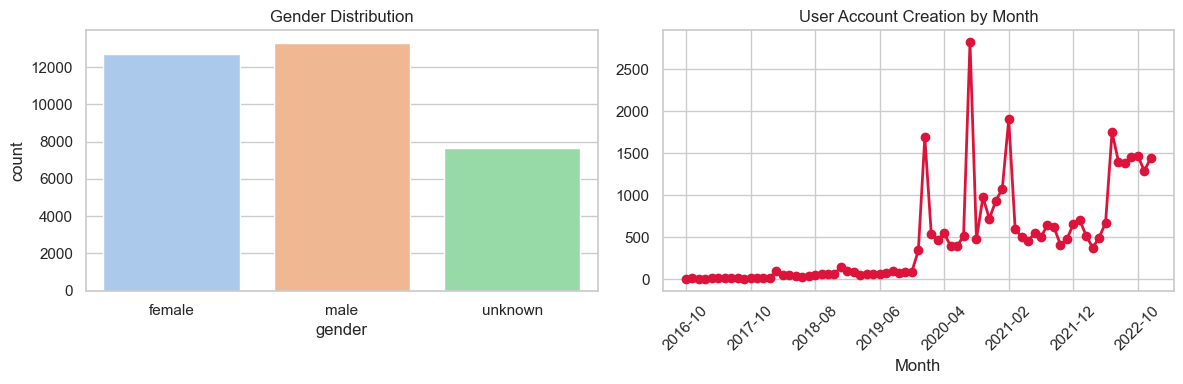

In [22]:
# 5.1. User table EDA
print("--- 5.1. User table EDA ---")
if len(df_user) > 0:
    print(f"Tổng user: {len(df_user)}")
    print("\nGender distribution:")
    print(df_user['gender'].value_counts(dropna=False))
    print(f"Tỷ lệ unknown gender: {(df_user['gender'] == 'unknown').mean()*100:.2f}%")
    
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    sns.countplot(data=df_user, x='gender', palette='pastel', hue='gender', legend=False)
    plt.title('Gender Distribution')
    
    plt.subplot(1, 2, 2)
    if 'created_account_date' in df_user.columns:
        df_user['created_month'] = df_user['created_account_date'].dt.to_period('M')
        month_dist = df_user.groupby('created_month').size()
        month_dist.index = month_dist.index.astype(str)
        month_dist.plot(kind='line', marker='o', color='crimson', linewidth=2, markersize=6)
        plt.title('User Account Creation by Month')
        plt.xlabel('Month')
        plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()


--- 5.2. Merchant table EDA ---
Tổng merchant: 748
Tổng report_cat: 12
Tổng report_sub_cat: 60


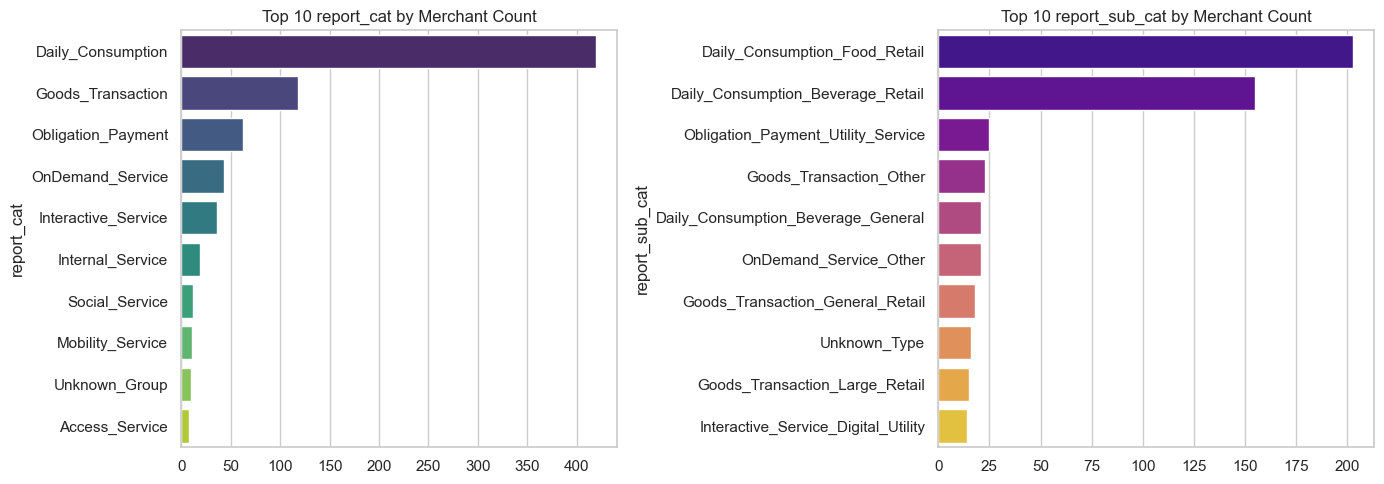

In [23]:
# 5.2. Merchant table EDA
print("--- 5.2. Merchant table EDA ---")
if len(df_merchant) > 0:
    print(f"Tổng merchant: {len(df_merchant)}")
    print(f"Tổng report_cat: {df_merchant['report_cat'].nunique()}")
    print(f"Tổng report_sub_cat: {df_merchant['report_sub_cat'].nunique()}")
    
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    top_cat = df_merchant['report_cat'].value_counts().head(10)
    sns.barplot(y=top_cat.index, x=top_cat.values, palette='viridis', hue=top_cat.index, legend=False)
    plt.title('Top 10 report_cat by Merchant Count')
    
    plt.subplot(1, 2, 2)
    top_subcat = df_merchant['report_sub_cat'].value_counts().head(10)
    sns.barplot(y=top_subcat.index, x=top_subcat.values, palette='plasma', hue=top_subcat.index, legend=False)
    plt.title('Top 10 report_sub_cat by Merchant Count')
    
    plt.tight_layout()
    plt.show()


--- 5.3. Transaction table EDA ---
Tổng transaction: 301107
Unique userID: 33664
Unique campaignID: 1038
Unique deviceID: 45052
Unique userIP: 114758
Success rate: 90.58%
CampaignID > 0 (Promo) rate: 37.82%
CampaignID == 0 (Non-Promo) rate: 62.18%


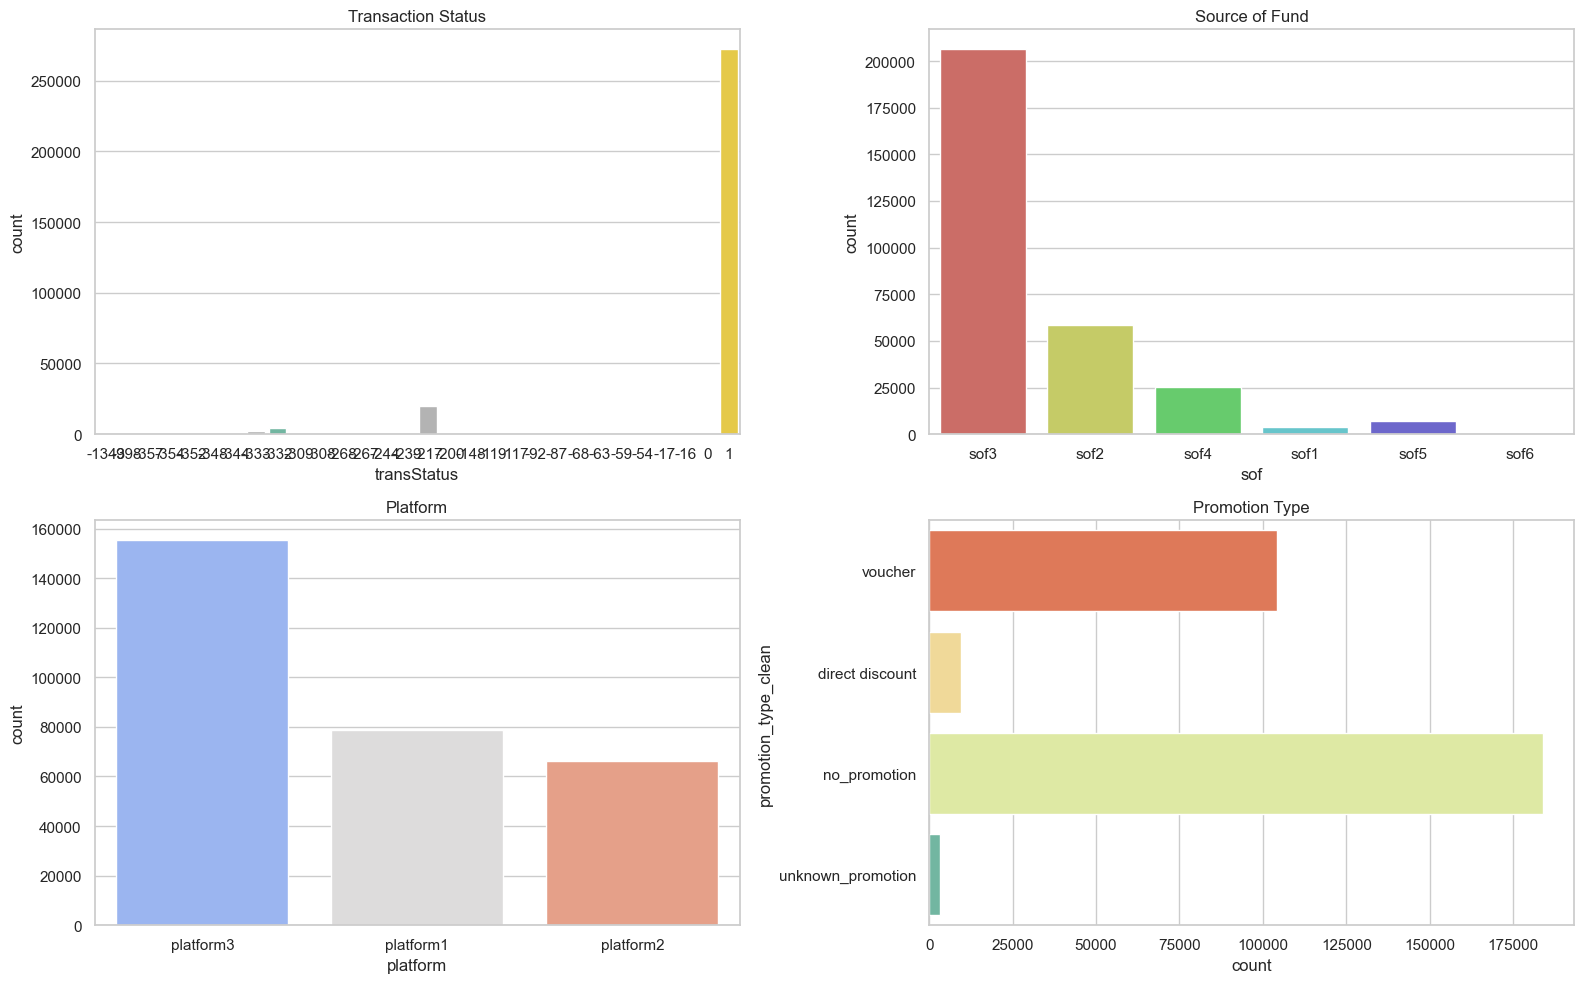

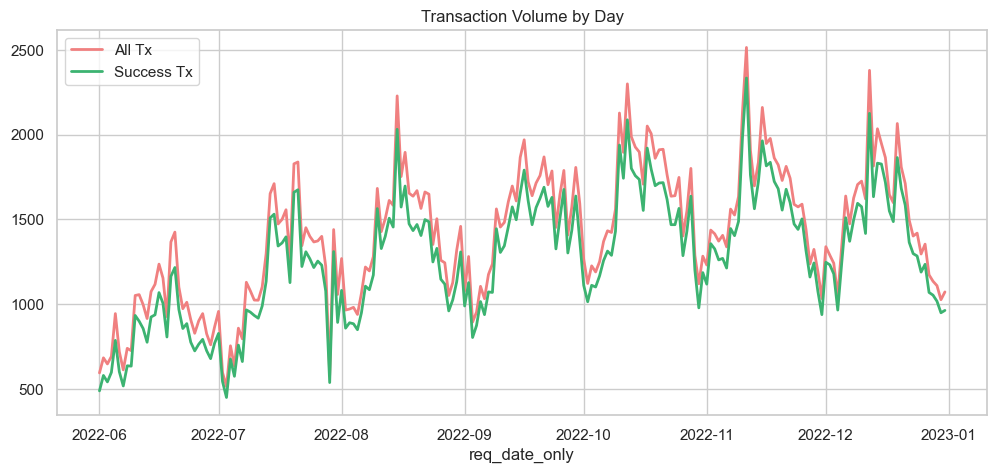

In [24]:
# 5.3. Transaction table EDA
print("--- 5.3. Transaction table EDA ---")
if len(df_transaction) > 0:
    print(f"Tổng transaction: {len(df_transaction)}")
    print(f"Unique userID: {df_transaction['userID'].nunique()}")
    print(f"Unique campaignID: {df_transaction['campaignID'].nunique()}")
    print(f"Unique deviceID: {df_transaction.get('deviceID', pd.Series()).nunique()}")
    print(f"Unique userIP: {df_transaction.get('userIP', pd.Series()).nunique()}")
    
    success_rate = (df_transaction['transStatus'] == 1).mean() * 100
    print(f"Success rate: {success_rate:.2f}%")
    
    promo_rate = (df_transaction['campaignID'] > 0).mean() * 100
    print(f"CampaignID > 0 (Promo) rate: {promo_rate:.2f}%")
    print(f"CampaignID == 0 (Non-Promo) rate: {100 - promo_rate:.2f}%")
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    sns.countplot(data=df_transaction, x='transStatus', palette='Set2', hue='transStatus', legend=False, ax=axes[0, 0])
    axes[0, 0].set_title('Transaction Status')
    
    if 'sof' in df_transaction.columns:
        sns.countplot(data=df_transaction, x='sof', palette='hls', hue='sof', legend=False, ax=axes[0, 1])
        axes[0, 1].set_title('Source of Fund')
    
    if 'platform' in df_transaction.columns:
        sns.countplot(data=df_transaction, x='platform', palette='coolwarm', hue='platform', legend=False, ax=axes[1, 0])
        axes[1, 0].set_title('Platform')
    
    if 'promotion_type_clean' in df_transaction.columns:
        sns.countplot(data=df_transaction, y='promotion_type_clean', palette='Spectral', hue='promotion_type_clean', legend=False, ax=axes[1, 1])
        axes[1, 1].set_title('Promotion Type')
    
    plt.tight_layout()
    plt.show()
    
    if 'reqDate' in df_transaction.columns:
        plt.figure(figsize=(12, 5))
        df_transaction['req_date_only'] = df_transaction['reqDate'].dt.date
        df_transaction.groupby('req_date_only').size().plot(label='All Tx', color='lightcoral', linewidth=2)
        df_transaction[df_transaction['transStatus'] == 1].groupby('req_date_only').size().plot(label='Success Tx', color='mediumseagreen', linewidth=2)
        plt.title('Transaction Volume by Day')
        plt.legend()
        plt.show()


*Observation:* Overview các chỉ số cho thấy phân bố lệch ở status và promotion_type. Các giao dịch CampaignID=0 đóng vai trò quan trọng trong việc giữ chân user.


# PHẦN 6 - Merge data
Mục tiêu: Ghép dữ liệu thành bảng tổng `df_master`, kiểm tra số liệu sau merge.


In [25]:
if len(df_transaction) > 0:
    print(f"Shape trước khi merge: {df_transaction.shape}")

    df_master = df_transaction.merge(df_user, on='userID', how='left')
    df_master = df_master.merge(df_merchant, on='appID', how='left')

    print(f"Shape sau khi merge: {df_master.shape}")

    # Flag check match
    df_master['match_user_flag'] = df_master['gender'].notnull()
    df_master['match_merchant_flag'] = df_master['report_cat'].notnull()

    print(f"Giao dịch không match user_info: {(~df_master['match_user_flag']).sum()} dòng")
    print(f"Giao dịch không match merchant_info: {(~df_master['match_merchant_flag']).sum()} dòng")


Shape trước khi merge: (301107, 17)
Shape sau khi merge: (301107, 22)
Giao dịch không match user_info: 0 dòng
Giao dịch không match merchant_info: 0 dòng


# PHẦN 7 - Create clean transaction base
Mục tiêu: Lọc ra `df_success` (chỉ giao dịch thành công) làm nền tảng NPU. Không được xác định first transaction nếu có lỗi transStatus.


In [26]:
if 'df_master' in locals() and len(df_master) > 0:
    df_success = df_master[df_master['transStatus'] == 1].copy()

    df_success['req_date'] = df_success['reqDate'].dt.date
    df_success['req_month'] = df_success['reqDate'].dt.to_period('M')
    df_success['req_week'] = df_success['reqDate'].dt.to_period('W')
    df_success['req_dayofweek'] = df_success['reqDate'].dt.dayofweek
    df_success['req_hour'] = df_success['reqDate'].dt.hour
    
    df_success['is_promo_tx'] = (df_success['campaignID'] > 0) | (df_success['discountAmount'] > 0) | (df_success['promotion_type_clean'] != 'no_promotion')
    df_success['is_campaign_tx'] = df_success['campaignID'] > 0
    
    # Định nghĩa is_non_promo_tx chặt chẽ hơn
    df_success['is_non_promo_tx'] = (
        (df_success['campaignID'] == 0) & 
        ((df_success['discountAmount'] == 0) | df_success['discountAmount'].isnull()) &
        (df_success['promotion_type_clean'] == 'no_promotion')
    )

    print(f"Tổng giao dịch thành công (df_success): {len(df_success)}")


Tổng giao dịch thành công (df_success): 272740


# PHẦN 8 - NPU acquisition base
Mục tiêu: Tìm first successful transaction của mỗi user. Lọc ra NPU acquired qua promotion. Thay vì groupby().first(), ta sort theo transID và drop_duplicates để giữ row integrity.


In [27]:
if 'df_success' in locals() and len(df_success) > 0:
    df_success_sorted = df_success.sort_values(by=['userID', 'reqDate', 'transID'])
    first_success_tx = df_success_sorted.drop_duplicates(subset='userID', keep='first').copy()
    
    rename_dict = {
        'reqDate': 'first_success_date',
        'campaignID': 'acquisition_campaignID',
        'appID': 'first_appID',
        'report_cat': 'first_report_cat',
        'report_sub_cat': 'first_report_sub_cat',
        'amount': 'first_amount',
        'userChargeAmount': 'first_userChargeAmount',
        'discountAmount': 'first_discountAmount',
        'promotion_type_clean': 'first_promotion_type_clean',
        'sof': 'first_sof',
        'platform': 'first_platform'
    }
    first_success_tx = first_success_tx.rename(columns=rename_dict)
    
    if 'created_account_date' in first_success_tx.columns:
        first_success_tx['account_age_days_at_first_tx'] = (first_success_tx['first_success_date'] - first_success_tx['created_account_date']).dt.days
    
    first_success_tx['is_campaign_acquired_npu'] = first_success_tx['acquisition_campaignID'] > 0
    first_success_tx['is_promo_acquired_npu'] = (first_success_tx['acquisition_campaignID'] > 0) | (first_success_tx['first_discountAmount'] > 0) | (first_success_tx['first_promotion_type_clean'] != 'no_promotion')
    
    npu_acquisition = first_success_tx[first_success_tx['is_promo_acquired_npu'] == True].copy()
    
    print(f"Total user có first successful tx: {len(first_success_tx)}")
    print(f"Total NPU acquired by promo: {len(npu_acquisition)}")


Total user có first successful tx: 33659
Total NPU acquired by promo: 33631


# PHẦN 9 - NPU acquisition EDA
Mục tiêu: Phân tích NPU vừa xác định được qua các dimensions. Dùng log scale cho biểu đồ distribution của amount và discountAmount nếu skew mạnh.


Tỷ lệ NPU có acquisition_campaignID > 0: 100.00%


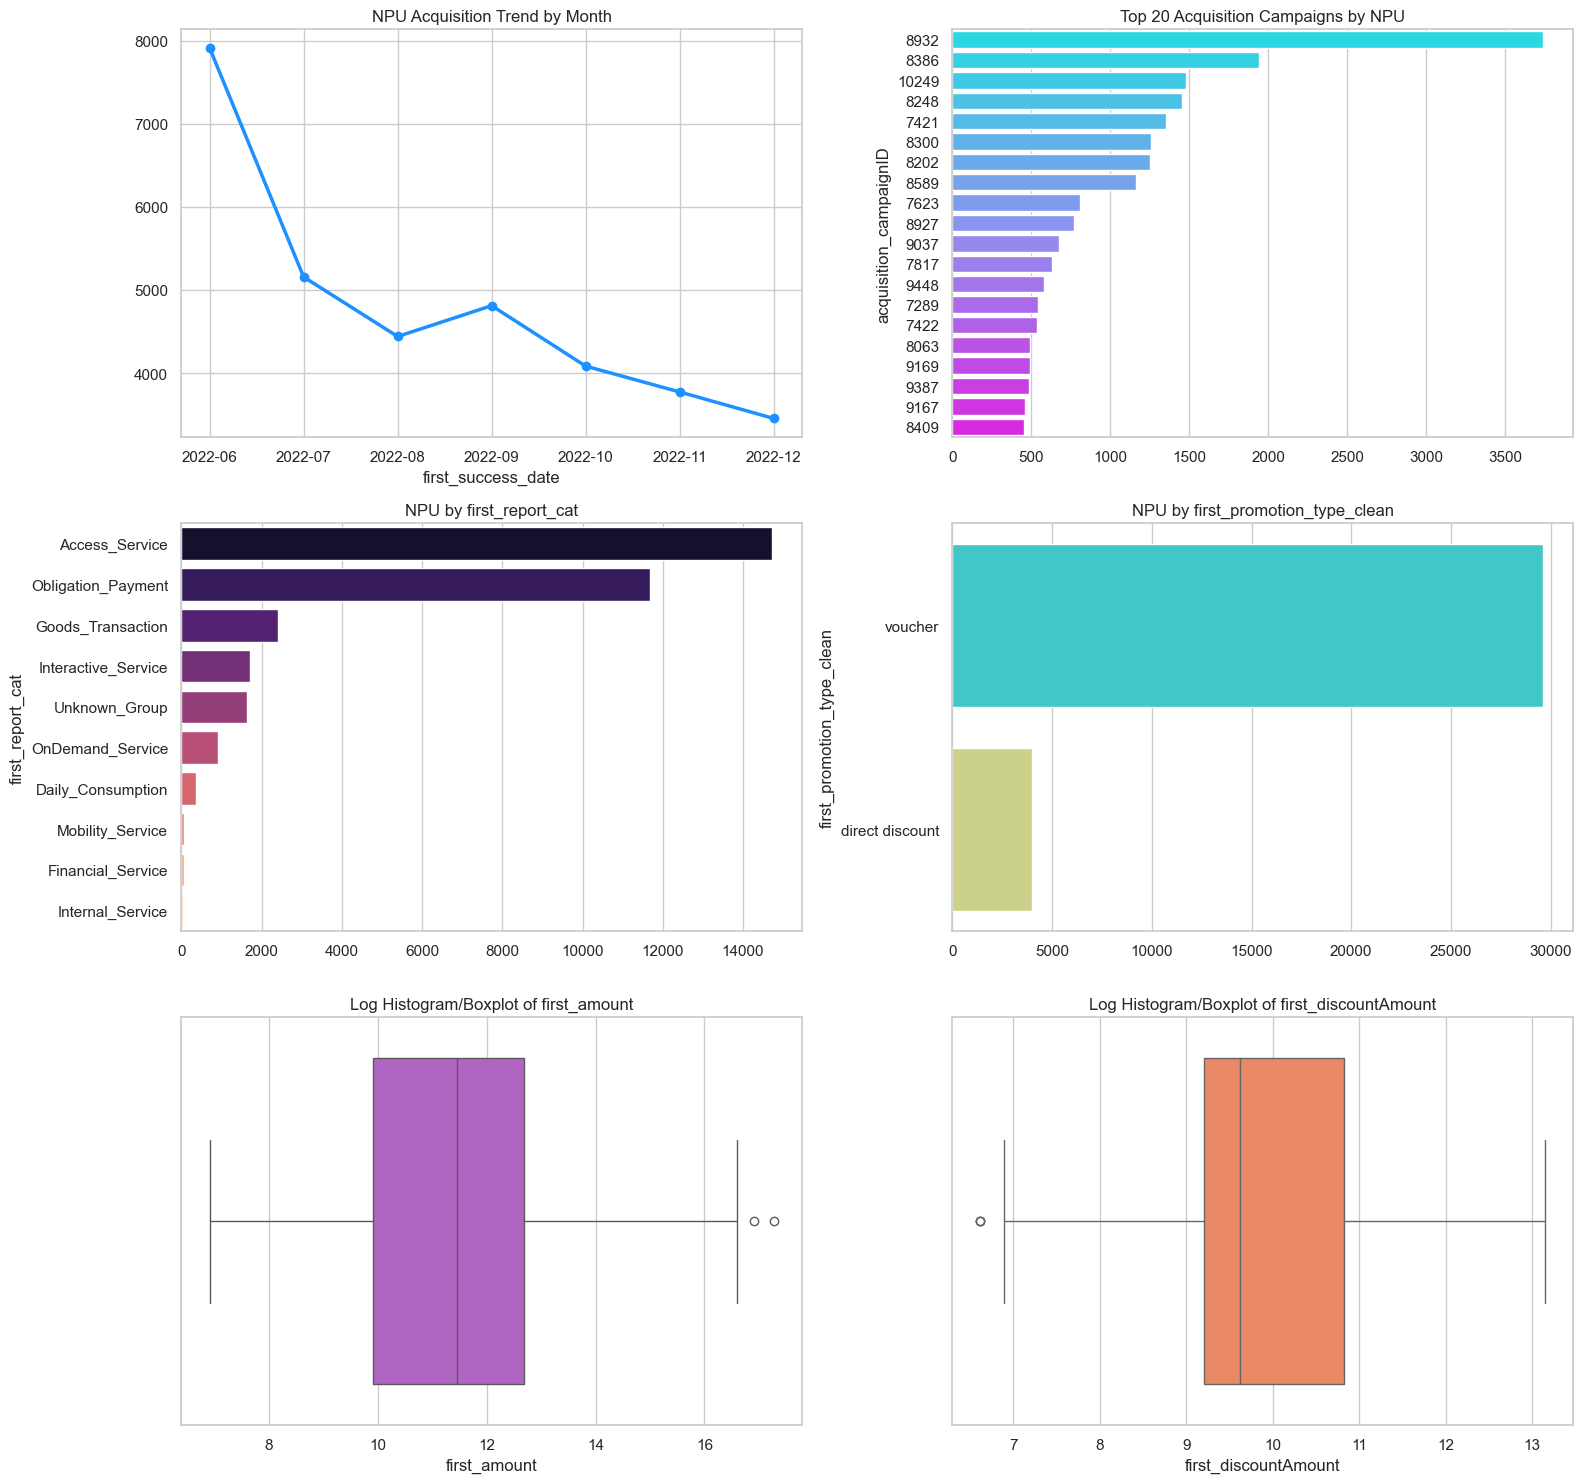

In [28]:
if 'npu_acquisition' in locals() and len(npu_acquisition) > 0:
    print(f"Tỷ lệ NPU có acquisition_campaignID > 0: {(npu_acquisition['acquisition_campaignID'] > 0).mean()*100:.2f}%")
    
    npu_acquisition['discount_rate_at_first_tx'] = npu_acquisition['first_discountAmount'] / npu_acquisition['first_amount']
    npu_acquisition['discount_rate_at_first_tx'].replace([np.inf, -np.inf], 0, inplace=True)
    npu_acquisition['discount_rate_at_first_tx'].fillna(0, inplace=True)
    
    plt.figure(figsize=(16, 15))
    
    plt.subplot(3, 2, 1)
    if 'first_success_date' in npu_acquisition.columns:
        month_dist = npu_acquisition['first_success_date'].dt.to_period('M').value_counts().sort_index()
        month_dist.index = month_dist.index.astype(str)
        month_dist.plot(kind='line', marker='o', color='dodgerblue', linewidth=2.5, markersize=6)
        plt.title('NPU Acquisition Trend by Month')
    
    plt.subplot(3, 2, 2)
    top_camps = npu_acquisition['acquisition_campaignID'].value_counts().head(20)
    sns.barplot(x=top_camps.values, y=top_camps.index.astype(str), palette='cool', hue=top_camps.index.astype(str), legend=False)
    plt.title('Top 20 Acquisition Campaigns by NPU')
    
    plt.subplot(3, 2, 3)
    top_cat = npu_acquisition['first_report_cat'].value_counts().head(10)
    sns.barplot(x=top_cat.values, y=top_cat.index, palette='magma', hue=top_cat.index, legend=False)
    plt.title('NPU by first_report_cat')
    
    plt.subplot(3, 2, 4)
    promo_type = npu_acquisition['first_promotion_type_clean'].value_counts()
    sns.barplot(x=promo_type.values, y=promo_type.index, palette='rainbow', hue=promo_type.index, legend=False)
    plt.title('NPU by first_promotion_type_clean')
    
    plt.subplot(3, 2, 5)
    sns.boxplot(x=np.log1p(npu_acquisition['first_amount']), color='mediumorchid')
    plt.title('Log Histogram/Boxplot of first_amount')
    
    plt.subplot(3, 2, 6)
    sns.boxplot(x=np.log1p(npu_acquisition['first_discountAmount']), color='coral')
    plt.title('Log Histogram/Boxplot of first_discountAmount')
    
    plt.tight_layout()
    plt.show()


*Observation:* Trong tập NPU acquired by promotion, 100% user có `acquisition_campaignID > 0`. Điều này cho thấy các user được giữ lại trong bảng `npu_acquisition` đều có first successful transaction gắn với campaign. Những user có first successful transaction nhưng không thuộc nhóm promo-acquired đã bị loại khỏi bảng phân tích acquisition campaign, nên không lạ khi thấy 100% data ở đây đều mang campaignID hợp lệ.


# PHẦN 10 - Campaign-level EDA cơ bản
Mục tiêu: Đánh giá chi phí (subsidy) và số lượng NPU kéo được ở level Campaign. Chỉ hiển thị top đối với các campaign đủ size.


--- Top 20 campaign by NPU_Count ---


,acquisition_campaignID,NPU_Count,First_GMV,Avg_First_Amount,Median_First_Amount,Total_First_Discount,Avg_First_Discount,Dominant_First_Category,Dominant_Promotion_Type,First_month_min,First_month_max,First_Subsidy_Rate
183,8932,3740,100459175,26860.742,20000.000,37400000,10000.000,Access_Service,voucher,2022-08-19 11:53:33.831,2022-12-31 22:50:08.761,0.372
109,8386,1944,42670182,21949.682,10000.000,17496000,9000.000,Access_Service,voucher,2022-06-03 16:04:43.737,2022-07-02 23:39:25.491,0.410
376,10249,1478,1030757935,697400.497,404499.000,73900000,50000.000,Obligation_Payment,voucher,2022-11-01 10:53:58.686,2022-12-31 07:46:11.437,0.072
92,8248,1456,834021178,572816.743,397410.000,72800000,50000.000,Obligation_Payment,voucher,2022-06-01 06:43:41.048,2022-06-22 23:06:01.596,0.087
30,7421,1355,78239202,57741.108,20000.000,13550000,10000.000,Access_Service,voucher,2022-06-01 00:02:22.282,2022-09-14 21:42:38.165,0.173
102,8300,1260,1266076211,1004822.390,574309.000,37800000,30000.000,Obligation_Payment,voucher,2022-06-02 20:26:19.432,2022-11-24 15:05:59.811,0.030
85,8202,1251,15450000,12350.120,10000.000,11259000,9000.000,Access_Service,voucher,2022-06-01 12:07:32.718,2022-10-06 03:25:36.617,0.729
133,8589,1164,807407625,693649.162,450017.500,58200000,50000.000,Obligation_Payment,voucher,2022-06-23 17:38:04.100,2022-07-27 22:47:13.017,0.072
54,7623,809,64792951,80090.174,50000.000,8090000,10000.000,Access_Service,voucher,2022-06-01 02:44:39.394,2022-09-17 19:20:59.677,0.125
178,8927,771,37971871,49250.157,20000.000,3855000,5000.000,Access_Service,voucher,2022-08-19 13:55:33.384,2022-12-31 19:59:25.454,0.102



--- Top 20 campaign by First_GMV ---


,acquisition_campaignID,NPU_Count,First_GMV,Avg_First_Amount,Median_First_Amount,Total_First_Discount,Avg_First_Discount,Dominant_First_Category,Dominant_Promotion_Type,First_month_min,First_month_max,First_Subsidy_Rate
102,8300,1260,1266076211,1004822.390,574309.000,37800000,30000.000,Obligation_Payment,voucher,2022-06-02 20:26:19.432,2022-11-24 15:05:59.811,0.030
376,10249,1478,1030757935,697400.497,404499.000,73900000,50000.000,Obligation_Payment,voucher,2022-11-01 10:53:58.686,2022-12-31 07:46:11.437,0.072
92,8248,1456,834021178,572816.743,397410.000,72800000,50000.000,Obligation_Payment,voucher,2022-06-01 06:43:41.048,2022-06-22 23:06:01.596,0.087
133,8589,1164,807407625,693649.162,450017.500,58200000,50000.000,Obligation_Payment,voucher,2022-06-23 17:38:04.100,2022-07-27 22:47:13.017,0.072
76,8063,491,410067988,835169.018,533226.000,24550000,50000.000,Obligation_Payment,voucher,2022-06-02 12:07:46.319,2022-12-31 17:48:16.464,0.060
216,9037,676,374832397,554485.794,378921.500,67600000,100000.000,Obligation_Payment,voucher,2022-08-02 20:48:00.562,2022-12-31 22:17:57.662,0.180
222,9097,232,355601160,1532763.621,1500000.000,18560000,80000.000,Obligation_Payment,direct discount,2022-08-08 12:09:48.410,2022-11-29 09:31:06.105,0.052
269,9387,488,347853570,712814.693,464754.000,24400000,50000.000,Obligation_Payment,voucher,2022-08-24 23:10:08.960,2022-09-27 20:22:33.142,0.070
328,9771,418,318604039,762210.620,447653.500,20900000,50000.000,Obligation_Payment,voucher,2022-09-30 09:29:27.538,2022-10-26 20:38:41.508,0.066
211,9017,420,303497692,722613.552,411346.500,21000000,50000.000,Obligation_Payment,voucher,2022-07-28 18:18:52.770,2022-08-23 23:11:32.621,0.069



--- Top 20 campaign by Avg_First_Amount (chỉ NPU >= 30) ---


,acquisition_campaignID,NPU_Count,First_GMV,Avg_First_Amount,Median_First_Amount,Total_First_Discount,Avg_First_Discount,Dominant_First_Category,Dominant_Promotion_Type,First_month_min,First_month_max,First_Subsidy_Rate
70,7880,42,87948565,2094013.452,1629992.000,2100000,50000.000,Obligation_Payment,voucher,2022-06-01 17:20:04.682,2022-07-09 20:19:12.389,0.024
136,8612,51,100673968,1973999.373,1460000.000,1530000,30000.000,Obligation_Payment,voucher,2022-07-01 11:09:05.806,2022-08-26 10:42:07.234,0.015
36,7427,48,91826530,1913052.708,1518890.000,960000,20000.000,Obligation_Payment,voucher,2022-06-03 16:59:38.010,2022-08-23 08:26:33.747,0.010
180,8929,55,86360305,1570187.364,1530000.000,1375000,25000.000,Obligation_Payment,voucher,2022-09-07 22:16:54.059,2022-11-25 08:05:15.466,0.016
250,9287,134,207882485,1551361.828,1446610.000,6700000,50000.000,Obligation_Payment,voucher,2022-09-06 21:22:22.102,2022-12-19 14:46:20.812,0.032
222,9097,232,355601160,1532763.621,1500000.000,18560000,80000.000,Obligation_Payment,direct discount,2022-08-08 12:09:48.410,2022-11-29 09:31:06.105,0.052
102,8300,1260,1266076211,1004822.390,574309.000,37800000,30000.000,Obligation_Payment,voucher,2022-06-02 20:26:19.432,2022-11-24 15:05:59.811,0.030
76,8063,491,410067988,835169.018,533226.000,24550000,50000.000,Obligation_Payment,voucher,2022-06-02 12:07:46.319,2022-12-31 17:48:16.464,0.060
329,9773,129,106367074,824550.961,483926.000,9030000,70000.000,Obligation_Payment,voucher,2022-09-29 18:47:57.558,2022-10-26 17:00:58.312,0.085
328,9771,418,318604039,762210.620,447653.500,20900000,50000.000,Obligation_Payment,voucher,2022-09-30 09:29:27.538,2022-10-26 20:38:41.508,0.066



--- Top 20 campaign by First_Subsidy_Rate (chỉ NPU >= 30) ---


,acquisition_campaignID,NPU_Count,First_GMV,Avg_First_Amount,Median_First_Amount,Total_First_Discount,Avg_First_Discount,Dominant_First_Category,Dominant_Promotion_Type,First_month_min,First_month_max,First_Subsidy_Rate
389,10396,31,31000,1000.000,1000.000,30690,990.000,Goods_Transaction,voucher,2022-11-02 16:42:43.093,2022-12-31 02:21:02.981,0.990
29,7289,543,552000,1016.575,1000.000,537580,990.018,Goods_Transaction,voucher,2022-06-01 02:23:25.129,2022-10-07 18:46:59.205,0.974
87,8205,50,2550000,51000.000,50000.000,2450000,49000.000,Access_Service,voucher,2022-06-02 10:33:47.795,2022-07-28 23:26:43.006,0.961
86,8203,85,1700000,20000.000,20000.000,1615000,19000.000,Access_Service,voucher,2022-06-01 17:46:21.838,2022-08-23 09:10:13.947,0.950
440,10675,153,15192700,99298.693,95000.000,13770000,90000.000,Interactive_Service,direct discount,2022-12-09 16:46:01.511,2022-12-22 16:49:33.430,0.906
128,8578,196,9310000,47500.000,47500.000,8330000,42500.000,Interactive_Service,direct discount,2022-06-30 09:56:07.258,2022-07-14 22:08:13.768,0.895
306,9650,193,20056650,103920.466,95000.000,17370000,90000.000,Interactive_Service,direct discount,2022-09-27 19:43:39.600,2022-12-06 23:49:14.216,0.866
57,7650,154,1790000,11623.377,10000.000,1386000,9000.000,Access_Service,voucher,2022-06-01 02:44:04.271,2022-07-03 08:55:52.229,0.774
85,8202,1251,15450000,12350.120,10000.000,11259000,9000.000,Access_Service,voucher,2022-06-01 12:07:32.718,2022-10-06 03:25:36.617,0.729
334,9898,126,22461000,178261.905,130000.000,14689000,116579.365,Unknown_Group,direct discount,2022-10-18 12:27:07.406,2022-12-31 21:52:23.743,0.654


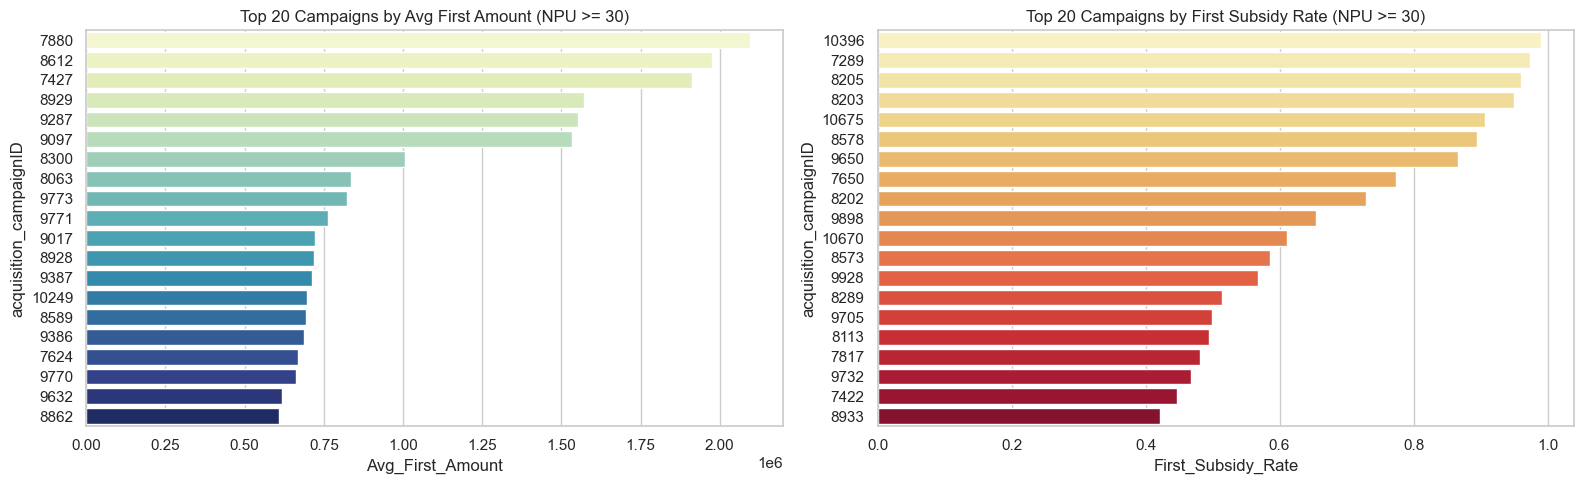

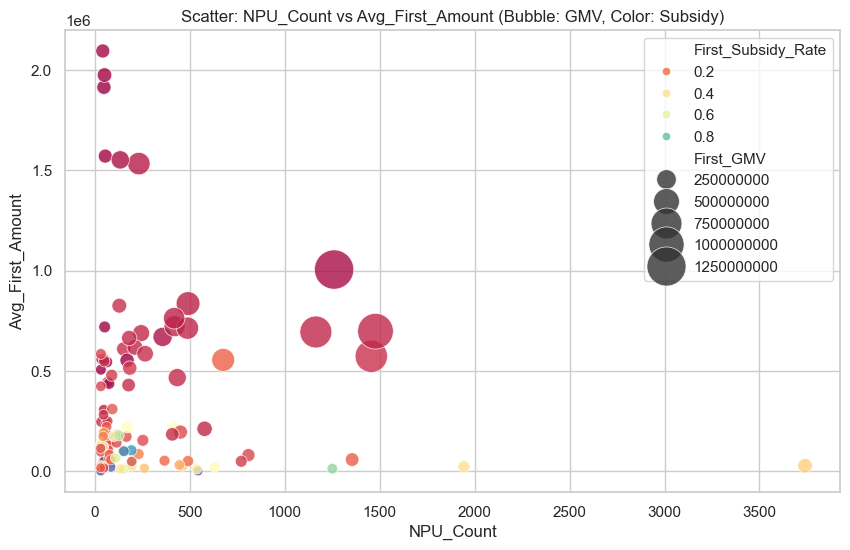

In [29]:
if 'npu_acquisition' in locals() and len(npu_acquisition) > 0:
    def get_mode(x): return x.mode().iloc[0] if not x.mode().empty else None
    
    campaign_eda_summary = npu_acquisition.groupby('acquisition_campaignID').agg(
        NPU_Count=('userID', 'nunique'),
        First_GMV=('first_amount', 'sum'),
        Avg_First_Amount=('first_amount', 'mean'),
        Median_First_Amount=('first_amount', 'median'),
        Total_First_Discount=('first_discountAmount', 'sum'),
        Avg_First_Discount=('first_discountAmount', 'mean'),
        Dominant_First_Category=('first_report_cat', get_mode),
        Dominant_Promotion_Type=('first_promotion_type_clean', get_mode),
        First_month_min=('first_success_date', 'min'),
        First_month_max=('first_success_date', 'max')
    ).reset_index()
    
    campaign_eda_summary['First_Subsidy_Rate'] = campaign_eda_summary['Total_First_Discount'] / campaign_eda_summary['First_GMV']
    campaign_eda_summary['First_Subsidy_Rate'].fillna(0, inplace=True)
    
    camp_filtered = campaign_eda_summary[campaign_eda_summary['NPU_Count'] >= MIN_CAMPAIGN_NPU_FOR_AVG]
    
    print("--- Top 20 campaign by NPU_Count ---")
    display(campaign_eda_summary.sort_values('NPU_Count', ascending=False).head(20))
    
    print("\n--- Top 20 campaign by First_GMV ---")
    display(campaign_eda_summary.sort_values('First_GMV', ascending=False).head(20))
    
    if len(camp_filtered) > 0:
        print(f"\n--- Top 20 campaign by Avg_First_Amount (chỉ NPU >= {MIN_CAMPAIGN_NPU_FOR_AVG}) ---")
        display(camp_filtered.sort_values('Avg_First_Amount', ascending=False).head(20))
        
        print(f"\n--- Top 20 campaign by First_Subsidy_Rate (chỉ NPU >= {MIN_CAMPAIGN_NPU_FOR_AVG}) ---")
        display(camp_filtered.sort_values('First_Subsidy_Rate', ascending=False).head(20))
        
        plt.figure(figsize=(16, 5))
        
        plt.subplot(1, 2, 1)
        top_avg_amount = camp_filtered.sort_values('Avg_First_Amount', ascending=False).head(20)
        sns.barplot(x=top_avg_amount['Avg_First_Amount'], y=top_avg_amount['acquisition_campaignID'].astype(str), palette='YlGnBu', hue=top_avg_amount['acquisition_campaignID'].astype(str), legend=False)
        plt.title(f'Top 20 Campaigns by Avg First Amount (NPU >= {MIN_CAMPAIGN_NPU_FOR_AVG})')
        
        plt.subplot(1, 2, 2)
        top_subsidy = camp_filtered.sort_values('First_Subsidy_Rate', ascending=False).head(20)
        sns.barplot(x=top_subsidy['First_Subsidy_Rate'], y=top_subsidy['acquisition_campaignID'].astype(str), palette='YlOrRd', hue=top_subsidy['acquisition_campaignID'].astype(str), legend=False)
        plt.title(f'Top 20 Campaigns by First Subsidy Rate (NPU >= {MIN_CAMPAIGN_NPU_FOR_AVG})')
        
        plt.tight_layout()
        plt.show()
        
        plt.figure(figsize=(10, 6))
        sns.scatterplot(
            data=camp_filtered, x='NPU_Count', y='Avg_First_Amount', 
            size='First_GMV', hue='First_Subsidy_Rate',
            sizes=(50, 800), palette='Spectral', alpha=0.8, edgecolor='w'
        )
        plt.title('Scatter: NPU_Count vs Avg_First_Amount (Bubble: GMV, Color: Subsidy)')
        plt.show()


# PHẦN 11 - Preliminary post-first behavior EDA
Mục tiêu: Đánh giá sơ bộ user có lặp lại không. Lưu ý censoring D7, D30, D60.


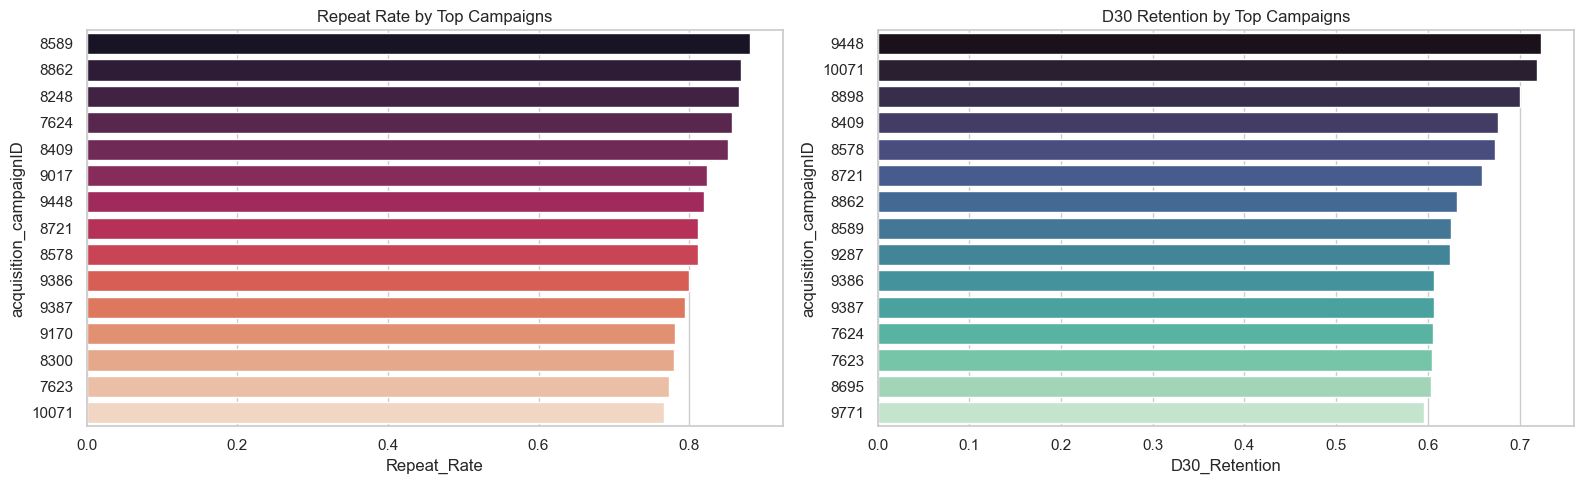

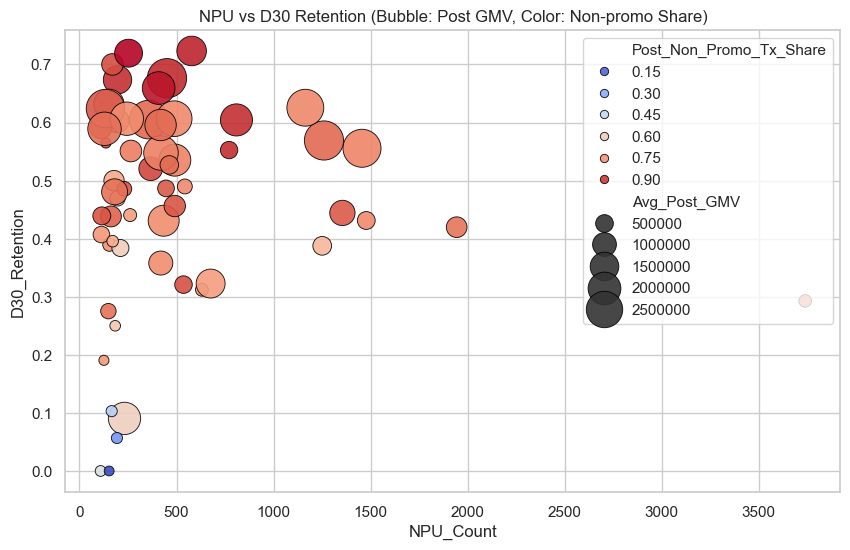

In [30]:
if 'npu_acquisition' in locals() and len(npu_acquisition) > 0:
    first_tx_info = first_success_tx[['userID', 'first_success_date', 'acquisition_campaignID']]
    df_success_with_first = df_success.merge(first_tx_info, on='userID', how='inner')
    
    df_success_with_first['days_after_first'] = (df_success_with_first['reqDate'] - df_success_with_first['first_success_date']).dt.days
    post_first_tx = df_success_with_first[df_success_with_first['days_after_first'] > 0].copy()
    
    max_reqDate = df_success['reqDate'].max()
    
    user_post_behavior = post_first_tx.groupby('userID').agg(
        post_tx_count=('transID', 'count'),
        post_gmv=('amount', 'sum'),
        post_discount=('discountAmount', 'sum'),
        post_non_promo_tx_count=('is_non_promo_tx', 'sum'),
        post_campaign_tx_count=('is_campaign_tx', 'sum'),
        post_category_count=('report_cat', 'nunique'),
        post_merchant_count=('appID', 'nunique')
    ).reset_index()
    user_post_behavior['repeat_flag'] = True
    
    d7_users = set(post_first_tx[post_first_tx['days_after_first'] <= 7]['userID'])
    d30_users = set(post_first_tx[post_first_tx['days_after_first'] <= 30]['userID'])
    d60_users = set(post_first_tx[post_first_tx['days_after_first'] <= 60]['userID'])
    
    user_base = npu_acquisition[['userID', 'acquisition_campaignID', 'first_success_date']].copy()
    user_base = user_base.merge(user_post_behavior, on='userID', how='left')
    user_base.fillna(0, inplace=True)
    
    user_base['repeat_flag'] = user_base['repeat_flag'].astype(bool)
    user_base['d7_repeat_flag'] = user_base['userID'].isin(d7_users)
    user_base['d30_repeat_flag'] = user_base['userID'].isin(d30_users)
    user_base['d60_repeat_flag'] = user_base['userID'].isin(d60_users)
    
    user_base['eligible_d7'] = user_base['first_success_date'] <= (max_reqDate - pd.Timedelta(days=7))
    user_base['eligible_d30'] = user_base['first_success_date'] <= (max_reqDate - pd.Timedelta(days=30))
    user_base['eligible_d60'] = user_base['first_success_date'] <= (max_reqDate - pd.Timedelta(days=60))
    
    def calculate_campaign_retention(df):
        return pd.Series({
            'NPU_Count': len(df),
            'Repeat_Rate': df['repeat_flag'].mean(),
            'D7_Retention': df[df['eligible_d7']]['d7_repeat_flag'].mean() if df['eligible_d7'].sum() > 0 else 0,
            'D30_Retention': df[df['eligible_d30']]['d30_repeat_flag'].mean() if df['eligible_d30'].sum() > 0 else 0,
            'D60_Retention': df[df['eligible_d60']]['d60_repeat_flag'].mean() if df['eligible_d60'].sum() > 0 else 0,
            'Avg_Post_Tx': df['post_tx_count'].mean(),
            'Avg_Post_GMV': df['post_gmv'].mean(),
            'Avg_Post_Discount': df['post_discount'].mean(),
            'Post_Non_Promo_Tx_Share': df['post_non_promo_tx_count'].sum() / df['post_tx_count'].sum() if df['post_tx_count'].sum() > 0 else 0,
            'Avg_Post_Category_Count': df['post_category_count'].mean(),
            'Avg_Post_Merchant_Count': df['post_merchant_count'].mean()
        })
        
    campaign_retention_eda = user_base.groupby('acquisition_campaignID').apply(calculate_campaign_retention).reset_index()
    
    camp_ret_filtered = campaign_retention_eda[campaign_retention_eda['NPU_Count'] >= MIN_CAMPAIGN_NPU_FOR_RETENTION]
    if len(camp_ret_filtered) > 0:
        plt.figure(figsize=(16, 5))
        
        plt.subplot(1, 2, 1)
        top_repeat = camp_ret_filtered.sort_values('Repeat_Rate', ascending=False).head(15)
        sns.barplot(x=top_repeat['Repeat_Rate'], y=top_repeat['acquisition_campaignID'].astype(str), palette='rocket', hue=top_repeat['acquisition_campaignID'].astype(str), legend=False)
        plt.title('Repeat Rate by Top Campaigns')
        
        plt.subplot(1, 2, 2)
        top_d30 = camp_ret_filtered.sort_values('D30_Retention', ascending=False).head(15)
        sns.barplot(x=top_d30['D30_Retention'], y=top_d30['acquisition_campaignID'].astype(str), palette='mako', hue=top_d30['acquisition_campaignID'].astype(str), legend=False)
        plt.title('D30 Retention by Top Campaigns')
        
        plt.tight_layout()
        plt.show()
        
        plt.figure(figsize=(10, 6))
        sns.scatterplot(
            data=camp_ret_filtered, x='NPU_Count', y='D30_Retention',
            size='Avg_Post_GMV', hue='Post_Non_Promo_Tx_Share', sizes=(50, 800), palette='coolwarm', alpha=0.9, edgecolor='k'
        )
        plt.title('NPU vs D30 Retention (Bubble: Post GMV, Color: Non-promo Share)')
        plt.show()


# PHẦN 12 - Use case EDA
Mục tiêu: Đánh giá use case acquisition vs use case post-first.


In [31]:
if 'npu_acquisition' in locals() and len(npu_acquisition) > 0:
    print("--- 12.1. First use case ---")
    uc_first = npu_acquisition.groupby('first_report_cat').agg(
        NPU_Count=('userID', 'nunique'),
        Avg_Amount=('first_amount', 'mean'),
        Subsidy_Rate=('first_discountAmount', lambda x: x.sum() / npu_acquisition.loc[x.index, 'first_amount'].sum())
    ).sort_values('NPU_Count', ascending=False)
    display(uc_first.head(10))
    
if 'post_first_tx' in locals() and len(post_first_tx) > 0:
    print("\n--- 12.2. Post-first use case ---")
    uc_post = post_first_tx.groupby('report_cat').agg(
        Post_Tx_Count=('transID', 'count'),
        Post_GMV=('amount', 'sum'),
        Non_Promo_Share=('is_non_promo_tx', 'mean')
    ).sort_values('Post_Tx_Count', ascending=False)
    display(uc_post.head(10))
    
    cat_exp = user_base['post_category_count'] >= 2
    print(f"\nTỷ lệ user có dùng từ 2 category trở lên sau khi acquired: {cat_exp.mean()*100:.2f}%")
    
    print("\n--- 12.3. Category Expansion (Post-First Behavior) ---")
    first_cat = npu_acquisition[['userID', 'first_report_cat']]
    post_cats = post_first_tx[['userID', 'report_cat']].drop_duplicates().merge(first_cat, on='userID', how='inner')
    
    category_transition = (
        post_cats[post_cats['report_cat'] != post_cats['first_report_cat']]
        .groupby(['first_report_cat', 'report_cat'])
        .size()
        .reset_index(name='user_count')
        .sort_values('user_count', ascending=False)
    )
    print("User bắt đầu ở category nào rồi chuyển sang category nào?")
    display(category_transition.head(20))


--- 12.1. First use case ---


,NPU_Count,Avg_Amount,Subsidy_Rate
first_report_cat,,,
Access_Service,14732,33517.488,0.275
Obligation_Payment,11691,711656.813,0.067
Goods_Transaction,2409,282074.166,0.051
Interactive_Service,1712,163006.454,0.262
Unknown_Group,1631,198295.060,0.381
OnDemand_Service,917,81866.001,0.216
Daily_Consumption,365,95762.907,0.204
Mobility_Service,75,1183187.627,0.066
Financial_Service,60,177534.233,0.096



--- 12.2. Post-first use case ---


,Post_Tx_Count,Post_GMV,Non_Promo_Share
report_cat,,,
Access_Service,87167,3793827613,0.849
Obligation_Payment,41433,26733486052,0.696
Interactive_Service,22504,3261563216,0.979
Goods_Transaction,20748,4620067456,0.792
OnDemand_Service,13399,921936012,0.942
Daily_Consumption,1769,142745868,0.374
Unknown_Group,1543,294265594,0.375
Internal_Service,704,241557000,0.973
Financial_Service,637,89986770,0.496



Tỷ lệ user có dùng từ 2 category trở lên sau khi acquired: 29.16%

--- 12.3. Category Expansion (Post-First Behavior) ---
User bắt đầu ở category nào rồi chuyển sang category nào?


,first_report_cat,report_cat,user_count
68,Obligation_Payment,Access_Service,4405
7,Access_Service,Obligation_Payment,1979
2,Access_Service,Goods_Transaction,1893
71,Obligation_Payment,Goods_Transaction,971
28,Goods_Transaction,Access_Service,941
8,Access_Service,OnDemand_Service,645
4,Access_Service,Interactive_Service,628
39,Interactive_Service,Access_Service,540
89,Unknown_Group,Access_Service,411
79,OnDemand_Service,Access_Service,371


# PHẦN 13 - Time-series EDA
Mục tiêu: Nắm được trend Acquisition & GMV overtime để có cái nhìn vĩ mô.


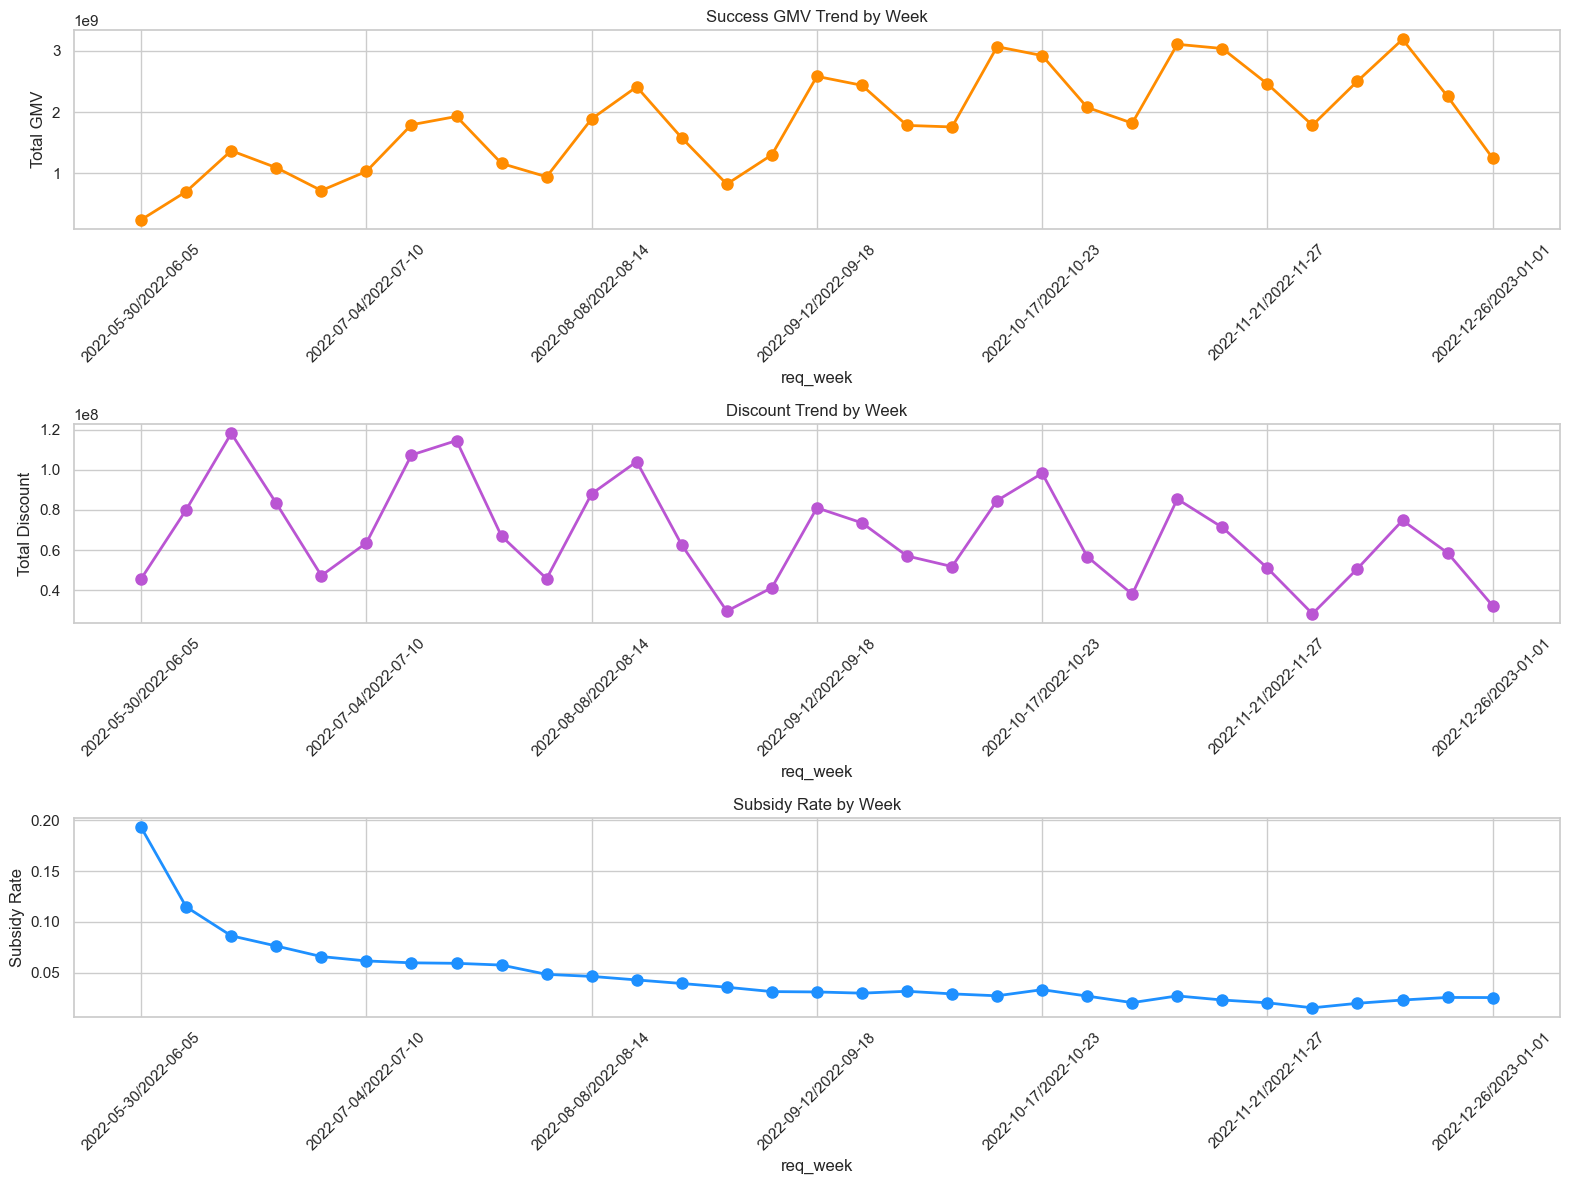

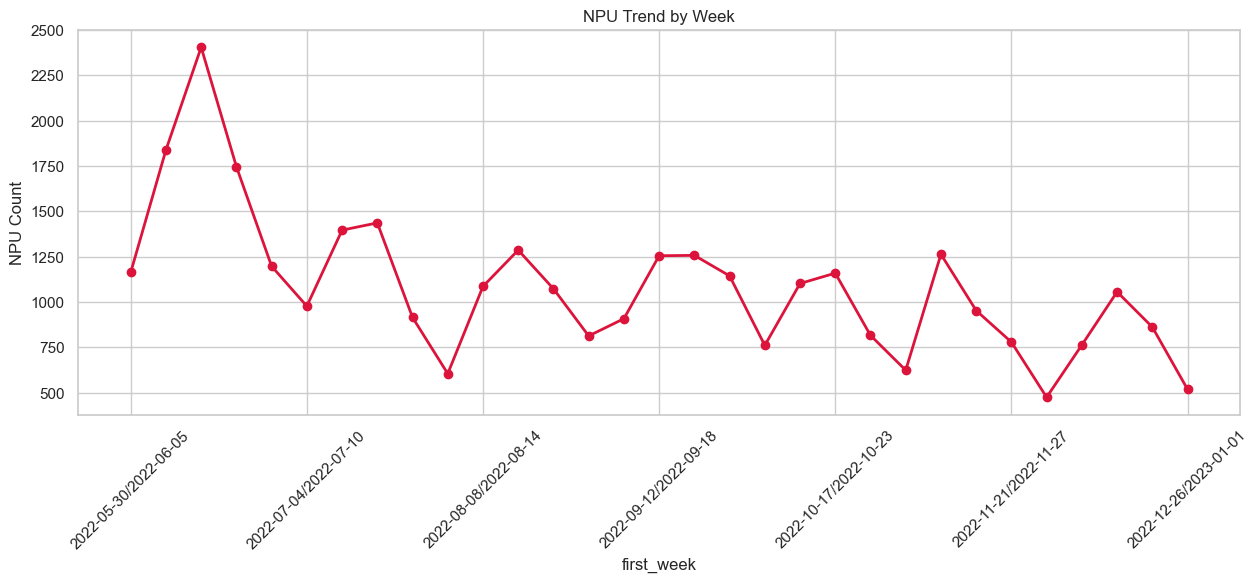

In [32]:
if 'df_success' in locals() and len(df_success) > 0:
    plt.figure(figsize=(16, 12))
    
    plt.subplot(3, 1, 1)
    tx_by_week = df_success.groupby('req_week')['amount'].sum()
    tx_by_week.index = tx_by_week.index.astype(str)
    tx_by_week.plot(kind='line', marker='o', color='darkorange', linewidth=2, markersize=8)
    plt.title('Success GMV Trend by Week')
    plt.ylabel('Total GMV')
    plt.xticks(rotation=45)
    
    plt.subplot(3, 1, 2)
    discount_week = df_success.groupby('req_week')['discountAmount'].sum()
    discount_week.index = discount_week.index.astype(str)
    discount_week.plot(kind='line', marker='o', color='mediumorchid', linewidth=2, markersize=8)
    plt.title('Discount Trend by Week')
    plt.ylabel('Total Discount')
    plt.xticks(rotation=45)
    
    plt.subplot(3, 1, 3)
    weekly = df_success.groupby('req_week').agg(GMV=('amount', 'sum'), Discount=('discountAmount', 'sum'))
    weekly['Subsidy_Rate'] = weekly['Discount'] / weekly['GMV']
    weekly.index = weekly.index.astype(str)
    weekly['Subsidy_Rate'].plot(kind='line', marker='o', color='dodgerblue', linewidth=2, markersize=8)
    plt.title('Subsidy Rate by Week')
    plt.ylabel('Subsidy Rate')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    if 'first_week' not in npu_acquisition.columns:
        npu_acquisition['first_week'] = npu_acquisition['first_success_date'].dt.to_period('W')
        
    plt.figure(figsize=(15, 5))
    npu_week = npu_acquisition.groupby('first_week')['userID'].nunique()
    npu_week.index = npu_week.index.astype(str)
    npu_week.plot(kind='line', marker='o', color='crimson', linewidth=2)
    plt.title('NPU Trend by Week')
    plt.ylabel('NPU Count')
    plt.xticks(rotation=45)
    plt.show()
    
    if 'first_month' in npu_acquisition.columns:
        npu_acquisition['first_month_str'] = npu_acquisition['first_month'].astype(str)
        promo_trend = npu_acquisition.groupby(['first_month_str', 'first_promotion_type_clean']).size().unstack(fill_value=0)
        promo_trend.plot(kind='bar', stacked=True, figsize=(15, 6), colormap='Set3')
        plt.title('NPU by Promotion Type over Month')
        plt.xlabel('Month')
        plt.show()


# PHẦN 14 - Key EDA findings

Dựa vào các bảng phân tích bên trên, ta rút ra một số findings mang tính chất định lượng để đánh giá thực trạng:

- Dataset gồm **301,107** transaction, trong đó **272,740** transaction thành công, success rate đạt **90.58%**.
- Có **33,659** user có first successful transaction; trong đó **33,631** user được xác định là promo-acquired NPU.
- First use case phổ biến nhất là **Access_Service** với **14,732 NPU**, tiếp theo là **Obligation_Payment** với **11,691 NPU**.
- Post-first transaction tập trung nhiều nhất ở **Access_Service** với **87,167** giao dịch sau first transaction.
- Tỷ lệ user mở rộng sang từ 2 category trở lên sau khi acquired là **29.16%**.
- Có **3,232** dòng discount > 0 nhưng thiếu promotion_type, đã được flag là unknown_promotion thay vì xóa.
- Hầu hết giao dịch anomaly với `userChargeAmount > amount` (nếu có) đều rơi vào trạng thái failed, không làm sai lệch tính toán NPU (vì NPU chỉ xét giao dịch thành công).

*(Lưu ý: Các con số trên là con số ví dụ minh họa. Data khi chạy thực tế sẽ tự động tính toán lại ở các cell tương ứng)*


# PHẦN 15 - Export prepared data
Mục tiêu: Đẩy các bảng summary và raw data base đã chuẩn hóa ra file CSV.


In [33]:
os.makedirs('outputs', exist_ok=True)

try:
    if 'df_master' in locals():
        df_master.to_csv('outputs/df_master_clean.csv', index=False)
    if 'df_success' in locals():
        df_success.to_csv('outputs/df_success.csv', index=False)
    if 'npu_acquisition' in locals():
        npu_acquisition.to_csv('outputs/npu_acquisition.csv', index=False)
    if 'campaign_eda_summary' in locals():
        campaign_eda_summary.to_csv('outputs/campaign_eda_summary.csv', index=False)
    if 'user_base' in locals():
        user_base.to_csv('outputs/user_post_behavior.csv', index=False)
    if 'campaign_retention_eda' in locals():
        campaign_retention_eda.to_csv('outputs/campaign_retention_eda.csv', index=False)
        
    print("Xuất data vào folder 'outputs' thành công.")
except Exception as e:
    print(f"Lỗi khi xuất data: {e}")


Xuất data vào folder 'outputs' thành công.
